In [2]:
import xarray as xr
import sys, os
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from cloudpathlib import AnyPath

# Local Imports
curdir = os.getcwd()
#print(curdir)
sys.path.insert(0, curdir+"/../../../data_processing")
from ceres_ebaf import *
from ceres_syn import *

sys.path.insert(0, curdir+"/../../../visualization")
from ceres_ebaf_plotting import *

base_path = AnyPath("/Users/mawa7160/dev/data/CERES/")
full_ebaf_filename = "EBAF/CERES_EBAF_Edition4.1_200003-202203.nc"
syn_part_1 = "SYN/CERES_SYN1deg-Day_Terra-Aqua-MODIS_Ed4.1_Subset_20000301-20200325.nc"
syn_part_2 = "SYN/CERES_SYN1deg-Day_Terra-Aqua-MODIS_Ed4.1_Subset_20200326-20240229.nc"

plt.rcParams['figure.figsize'] = [10, 3.5]

# Load the full SYN1deg data
syn_part_1_data = xr.open_dataset(base_path / syn_part_1)
syn_part_2_data = xr.open_dataset(base_path / syn_part_2)   
syn = xr.concat([syn_part_1_data, syn_part_2_data], dim='time')

In [3]:
# Make Syn Annual averages from Daily Data
start_year = 2003
syn_length = 21
years = np.arange(syn_length)+start_year
syn_solar = syn["toa_solar_all_daily"]
syn_correct_timing = syn_solar.sel(time=slice(f"{start_year-1}-12-31", f"{start_year+syn_length+1}-01-31"))

syn_global = apply_spatial_weights(syn_correct_timing, low_lat=-90, high_lat=90)
syn_nh = apply_spatial_weights(syn_correct_timing, low_lat=0, high_lat=90)
syn_sh = apply_spatial_weights(syn_correct_timing, low_lat=-90, high_lat=0)

In [4]:
# Make Syn Monthly averages from Daily Data by resampling
global_syn_monthly = syn_global.resample(time="1M").mean()
global_syn_monthly["time"] = global_syn_monthly.time - np.timedelta64(15, "D")
nh_syn_monthly = syn_nh.resample(time="1M").mean()
nh_syn_monthly["time"]  = nh_syn_monthly.time - np.timedelta64(15, "D")
sh_syn_monthly = syn_sh.resample(time="1M").mean()
sh_syn_monthly["time"] = sh_syn_monthly.time - np.timedelta64(15, "D")

In [55]:
global_syn_daily_means = np.ones(len(years), dtype=float)
nh_syn_daily_means = np.ones_like(global_syn_daily_means)
sh_syn_daily_means = np.ones_like(global_syn_daily_means)

LEAP_YEAR_DAY_LENGTH = 0.2422
LEAP_YEAR_OFFSET = .2422
NON_LEAP_YEAR_OFFSET = LEAP_YEAR_DAY_LENGTH/2
for i in range(len(years)):
    if years[i] % 4 == 1:
        offsets = [0, 1, 1, LEAP_YEAR_DAY_LENGTH]
    elif years[i] % 4 == 2:
        offsets = [0, 1-LEAP_YEAR_DAY_LENGTH, 1, 2*LEAP_YEAR_DAY_LENGTH]
    elif years[i] % 4 == 3:
        offsets = [0, 1-2*LEAP_YEAR_DAY_LENGTH, 1, 3*LEAP_YEAR_DAY_LENGTH]
    else:
        offsets = [0, LEAP_YEAR_DAY_LENGTH, 1, 0]
    global_syn_daily_means[i] = make_annual_mean_from_daily_syn_data_four_offsets(syn_global, years[i], offsets=offsets)
    nh_syn_daily_means[i] = make_annual_mean_from_daily_syn_data_four_offsets(syn_nh, years[i], offsets=offsets)
    sh_syn_daily_means[i] = make_annual_mean_from_daily_syn_data_four_offsets(syn_sh, years[i], offsets=offsets)

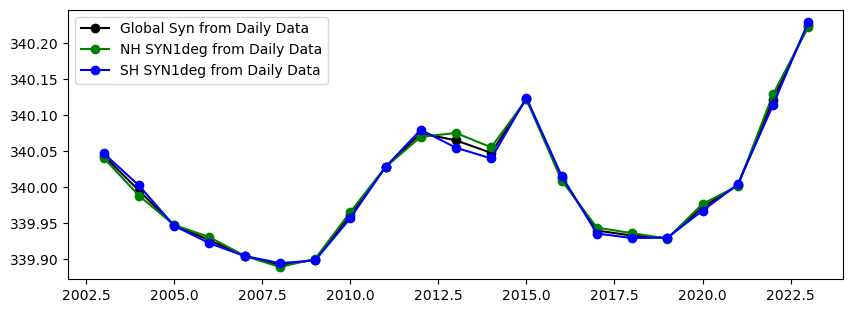

In [56]:
plt.plot(years, global_syn_daily_means, "-ok", label="Global Syn from Daily Data")
plt.plot(years, nh_syn_daily_means, "-og", label="NH SYN1deg from Daily Data")
plt.plot(years, sh_syn_daily_means, "-ob", label="SH SYN1deg from Daily Data")
plt.legend()
plt.show()

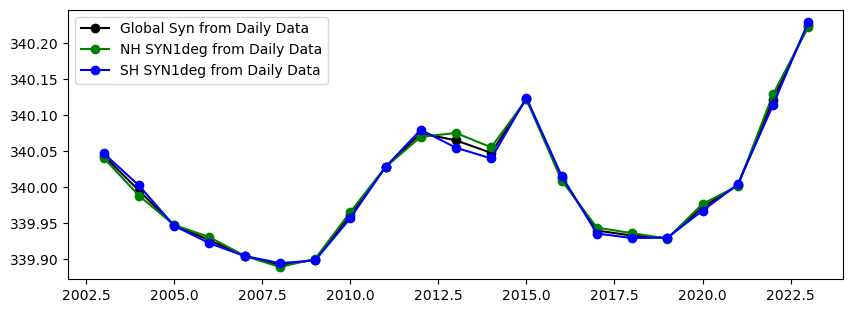

In [57]:
plt.plot(years, global_syn_daily_means, "-ok", label="Global Syn from Daily Data")
plt.plot(years, nh_syn_daily_means, "-og", label="NH SYN1deg from Daily Data")
plt.plot(years, sh_syn_daily_means, "-ob", label="SH SYN1deg from Daily Data")
plt.legend()
plt.show()

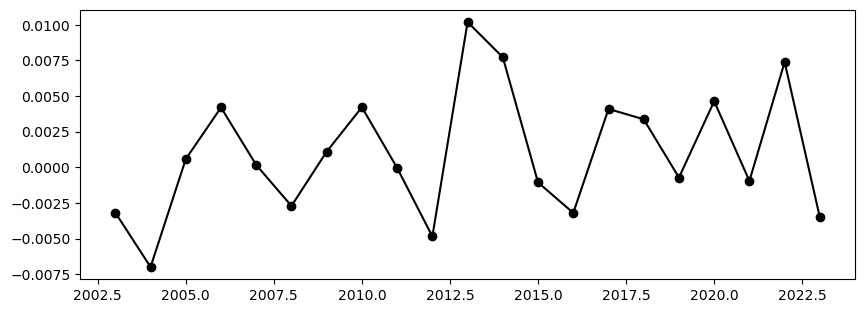

In [58]:
plt.plot(years, nh_syn_daily_means-global_syn_daily_means, "-ok", label="Global Syn from Daily Data")

In [89]:
LEAP_YEAR_OFFSET = -3.8263e-01
NON_LEAP_YEAR_OFFSET = 0.12141757
LEAP_YEAR_OFFSET = -4e-01
NON_LEAP_YEAR_OFFSET = 0.25/2
# Make annual Syn averages from Syn monthly data
global_syn_monthly_means = apply_time_averaging(global_syn_monthly, averaging_method=3, leap_year_offest=LEAP_YEAR_OFFSET, non_leap_year_offset=NON_LEAP_YEAR_OFFSET)
nh_syn_monthly_means = apply_time_averaging(nh_syn_monthly, averaging_method=3, leap_year_offest=LEAP_YEAR_OFFSET, non_leap_year_offset=NON_LEAP_YEAR_OFFSET)
sh_syn_monthly_means = apply_time_averaging(sh_syn_monthly, averaging_method=3, leap_year_offest=LEAP_YEAR_OFFSET, non_leap_year_offset=NON_LEAP_YEAR_OFFSET)

nh_syn_monthly_means_ok = apply_time_averaging(nh_syn_monthly, averaging_method=0)
nh_syn_monthly_means_bad = apply_time_averaging(nh_syn_monthly, averaging_method=-1)

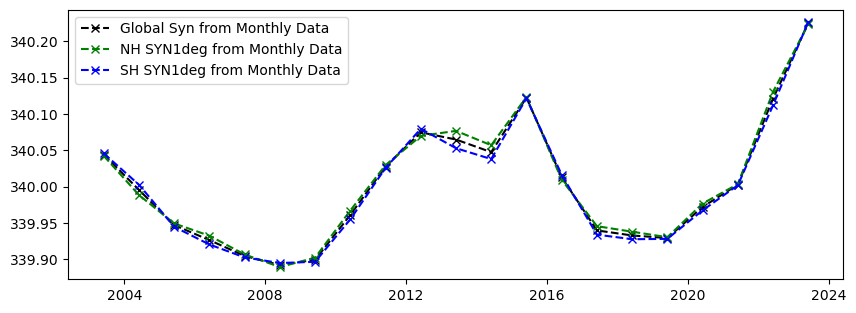

In [90]:
plt.plot(global_syn_monthly_means.year, global_syn_monthly_means, "--xk", label="Global Syn from Monthly Data")
plt.plot(nh_syn_monthly_means.year, nh_syn_monthly_means, "--xg", label="NH SYN1deg from Monthly Data")
plt.plot(sh_syn_monthly_means.year, sh_syn_monthly_means, "--xb", label="SH SYN1deg from Monthly Data")
plt.legend()

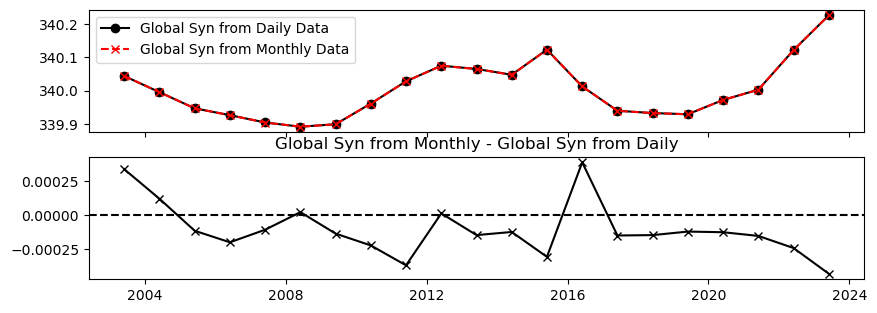

In [91]:
# Compare the two methods
# Subplot with Global to show the average from daily and monthly data first then below plot the difference
fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].plot(global_syn_monthly_means.year, global_syn_daily_means, "-ok", label="Global Syn from Daily Data")
axs[0].plot(global_syn_monthly_means.year, global_syn_monthly_means, "--xr", label="Global Syn from Monthly Data")
axs[0].legend()

axs[1].plot(global_syn_monthly_means.year, global_syn_monthly_means - global_syn_daily_means, "-xk")
#axs[1].plot(global_syn_monthly_means.year, nh_syn_monthly_means - nh_syn_daily_means, "-xg")
#axs[1].plot(global_syn_monthly_means.year, sh_syn_monthly_means - sh_syn_daily_means, "-xb")
axs[1].set_title("Global Syn from Monthly - Global Syn from Daily")
# add a reference line at 0
axs[1].axhline(0, color="k", linestyle="--")


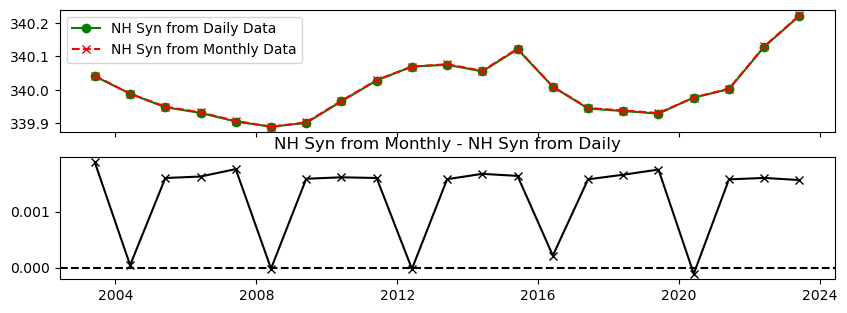

In [92]:
# Compare the two methods
# Subplot with Global to show the average from daily and monthly data first then below plot the difference
fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].plot(nh_syn_monthly_means.year, nh_syn_daily_means, "-og", label="NH Syn from Daily Data")
axs[0].plot(nh_syn_monthly_means.year, nh_syn_monthly_means, "--xr", label="NH Syn from Monthly Data")
axs[0].legend()

axs[1].plot(nh_syn_monthly_means.year, nh_syn_monthly_means - nh_syn_daily_means, "-xk")
#axs[1].plot(global_syn_monthly_means.year, nh_syn_monthly_means - nh_syn_daily_means, "-xg")
#axs[1].plot(global_syn_monthly_means.year, sh_syn_monthly_means - sh_syn_daily_means, "-xb")
axs[1].set_title("NH Syn from Monthly - NH Syn from Daily")
# add a reference line at 0
axs[1].axhline(0, color="k", linestyle="--")


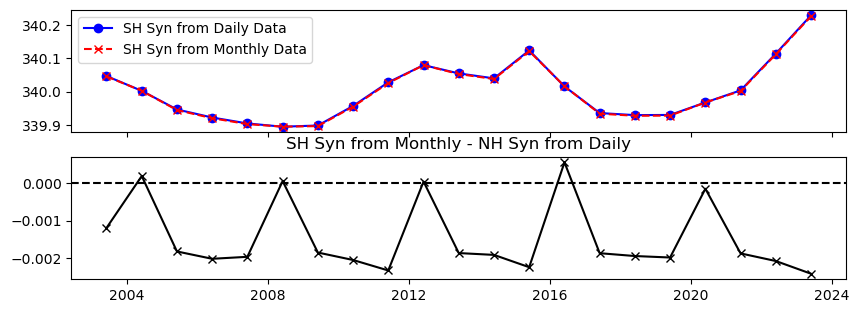

In [93]:
# Compare the two methods
# Subplot with Global to show the average from daily and monthly data first then below plot the difference
fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].plot(sh_syn_monthly_means.year, sh_syn_daily_means, "-ob", label="SH Syn from Daily Data")
axs[0].plot(sh_syn_monthly_means.year, sh_syn_monthly_means, "--xr", label="SH Syn from Monthly Data")
axs[0].legend()

axs[1].plot(sh_syn_monthly_means.year, sh_syn_monthly_means - sh_syn_daily_means, "-xk")
#axs[1].plot(global_syn_monthly_means.year, nh_syn_monthly_means - nh_syn_daily_means, "-xg")
#axs[1].plot(global_syn_monthly_means.year, sh_syn_monthly_means - sh_syn_daily_means, "-xb")
axs[1].set_title("SH Syn from Monthly - NH Syn from Daily")
# add a reference line at 0
axs[1].axhline(0, color="k", linestyle="--")


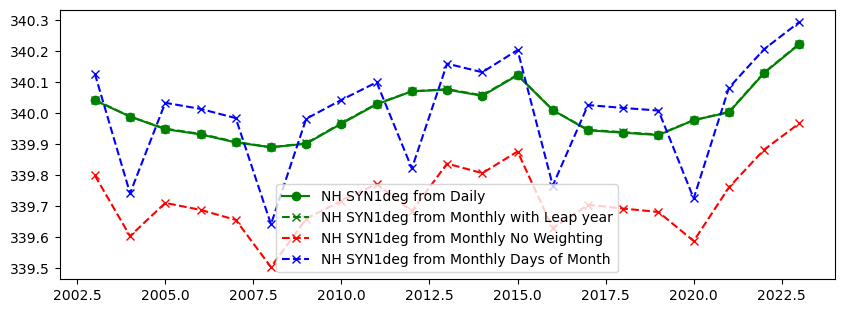

In [94]:
plt.plot(years, nh_syn_daily_means, "-og", label="NH SYN1deg from Daily")
plt.plot(years, nh_syn_monthly_means, "--xg", label="NH SYN1deg from Monthly with Leap year")
plt.plot(years, nh_syn_monthly_means_bad, "--xr", label="NH SYN1deg from Monthly No Weighting")
plt.plot(years, nh_syn_monthly_means_ok, "--xb", label="NH SYN1deg from Monthly Days of Month")
plt.legend()

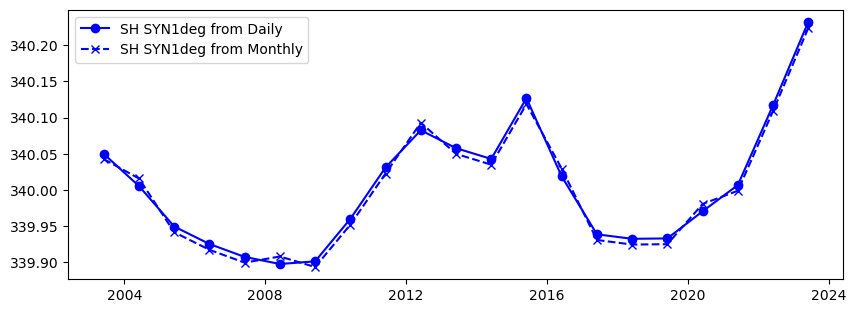

In [77]:
plt.plot(sh_syn_monthly_means.year, sh_syn_daily_means, "-ob", label="SH SYN1deg from Daily")
plt.plot(sh_syn_monthly_means.year, sh_syn_monthly_means, "--xb", label="SH SYN1deg from Monthly")
plt.legend()

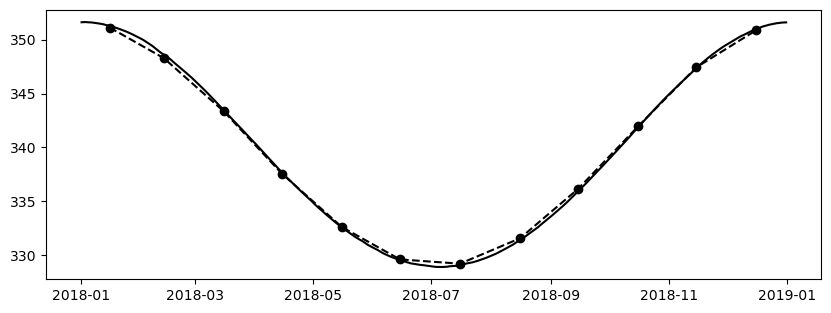

In [78]:
# Check out daily vs monthly averages for 1 year
syn_year = syn_global.sel(time=slice("2018-01-01", "2018-12-31"))
syn_month_year = global_syn_monthly.sel(time=slice("2018-01-01", "2018-12-31"))
plt.plot(syn_year.time, syn_year, "k")
plt.plot(syn_month_year.time, syn_month_year, "--ok")

# Try some optimizations
## 1. Single Adjustment for CERES Record

In [ ]:
predictions = global_syn_daily_means

predictions_non_ly = np.zeros(14, dtype=float)
years_non_ly_array = np.zeros(14, dtype=float)

predictions_ly = np.zeros(5, dtype=float)
years_ly_array = np.zeros(5, dtype=float)

ly_index = 0 
nly_index = 0

for i in range(len(years)):
    is_ly = years[i] % 4
    if years[i] == 2013:
        continue
    if years[i] == 2014:
        continue
    if is_ly == 0:
        years_ly_array[ly_index] = years[i]
        predictions_ly[ly_index] = predictions[i]
        ly_index = ly_index + 1
    else:
        years_non_ly_array[nly_index] = years[i]
        predictions_non_ly[nly_index] = predictions[i]
        nly_index = nly_index + 1
print(predictions_ly)
print(years_ly_array)

In [ ]:
def optimize_against_global_year(model_function, ref_data, year_array, prediction_data, initial_guess, method="Nelder-Mead"):
    def objective(optimized_params):
        y_est_array = np.array([])
        for year in year_array:
            year_int = year.astype(int)
            data_year = ref_data.sel(time=slice(f"{year_int - 1}-12-31", f"{year_int + 1}-01-01"))
            y_est_array = np.append(y_est_array, model_function(data_year, optimized_params))
        error = prediction_data - y_est_array
        print(np.sum(error ** 2))
        print(optimized_params)
        return np.sqrt(np.sum(error ** 2))

    result = minimize(objective, initial_guess, method=method, options={'ftol': 1e-32})
    return result

In [ ]:
nly_guess = 0
nly_optimal = optimize_against_global_year(annual_mean_from_monthly_data_two_extra_days_one_offset, syn_global, years_non_ly_array, predictions_non_ly, nly_guess, method="SLSQP")
print(nly_optimal)

ly_guess = -0.37875276
ly_optimal = optimize_against_global_year(annual_mean_from_monthly_data_two_extra_days_one_offset, syn_global, years_ly_array, predictions_ly, ly_guess, method="SLSQP")
print(ly_optimal)

In [ ]:
LEAP_YEAR_OFFSET = ly_optimal.x[0]
NON_LEAP_YEAR_OFFSET = nly_optimal.x[0]
# Make annual Syn averages from Syn monthly data
global_syn_monthly_means_opt = apply_time_averaging(global_syn_monthly, averaging_method=3, leap_year_offest=LEAP_YEAR_OFFSET, non_leap_year_offset=NON_LEAP_YEAR_OFFSET)
nh_syn_monthly_means_opt = apply_time_averaging(nh_syn_monthly, averaging_method=3, leap_year_offest=LEAP_YEAR_OFFSET, non_leap_year_offset=NON_LEAP_YEAR_OFFSET)
sh_syn_monthly_means_opt = apply_time_averaging(sh_syn_monthly, averaging_method=3, leap_year_offest=LEAP_YEAR_OFFSET, non_leap_year_offset=NON_LEAP_YEAR_OFFSET)

In [ ]:
print(np.sum((global_syn_monthly_means_opt - global_syn_daily_means) ** 2))
plt.plot(global_syn_monthly_means_opt.year, global_syn_monthly_means_opt - global_syn_daily_means, "-xk")
plt.plot(global_syn_monthly_means_opt.year, global_syn_monthly_means - global_syn_daily_means, "--xk")
#plt.plot(global_syn_monthly_means.year, nh_syn_monthly_means - nh_syn_daily_means, "-xg")
#axs[1].plot(global_syn_monthly_means.year, sh_syn_monthly_means - sh_syn_daily_means, "-xb")
plt.title("Global Syn from Monthly - Global Syn from Daily")
# add a reference line at 0
plt.axhline(0, color="k", linestyle="--")

In [ ]:
def model(years, offset):
    results = np.array([])
    for year in years:
        year_int = year.astype(int)
        syn_year = syn_global.sel(time=slice(f"{year_int - 1}-12-01", f"{year_int + 1}-01-31"))
        syn_14_month = syn_year.resample(time='M').mean()
        weightings = syn_14_month.time.dt.days_in_month.values.astype(float)
        weightings.put(0, offset)
        weightings.put(-1, offset)
        syn_weighted = syn_14_month.weighted(xr.DataArray(weightings, dims='time'))
        mean = syn_weighted.mean().values
        results = np.append(results, mean)
    return results

global_syn_monthly_means_fixed = apply_time_averaging(global_syn_monthly, averaging_method=2, leap_year_offest=ly_optimal.x, non_leap_year_offset=nly_optimal.x)
nly_data = model(years_non_ly_array, nly_optimal.x)
ly_data = model(years_ly_array, ly_optimal.x)

In [ ]:
plt.plot(years, global_syn_daily_means, "--ok", label="Global Syn from Daily Data")
plt.plot(years_ly_array, ly_data, "xr")
plt.plot(years_non_ly_array, nly_data, "xr")
#plt.plot(global_syn_monthly_means_fixed.year, global_syn_monthly_means_fixed, "--r")

In [ ]:

nh_syn_monthly_means_fixed = apply_time_averaging(nh_syn_monthly, averaging_method=2, leap_year_offest=ly_optimal.x, non_leap_year_offset=nly_optimal.x)
sh_syn_monthly_means_fixed = apply_time_averaging(sh_syn_monthly, averaging_method=2, leap_year_offest=ly_optimal.x, non_leap_year_offset=nly_optimal.x)

In [ ]:
plt.plot(global_syn_monthly_means_fixed.year, global_syn_monthly_means_fixed, "-ok", label="Global SYN1deg from Monthly")
plt.plot(years, nh_syn_daily_means, "-og", label="NH SYN1deg from Daily")
plt.plot(nh_syn_monthly_means_fixed.year, nh_syn_monthly_means_fixed, "--xg", label="NH SYN1deg from Monthly")
plt.plot(years, sh_syn_daily_means, "-ob", label="SH SYN1deg from Daily")
plt.plot(sh_syn_monthly_means_fixed.year, sh_syn_monthly_means_fixed, "--xb", label="sH SYN1deg from Monthly")
plt.legend()

In [ ]:
nh_opt_ly = optimize_with_global_year(annual_mean_from_daily_data_two_extra_days_one_offset, syn_nh, years_ly_array, syn_global, ly_guess)
sh_opt_ly = optimize_with_global_year(annual_mean_from_daily_data_two_extra_days_one_offset, syn_sh, years_ly_array, syn_global, ly_guess)
print(f"NH Optimal: {nh_opt_ly.x}")
print(f"SH Optimal: {sh_opt_ly.x}")

In [ ]:
nh_opt_nly = optimize_with_global_year(annual_mean_from_daily_data_two_extra_days_one_offset, syn_nh, years_non_ly_array, syn_global, nly_guess)
sh_opt_nly = optimize_with_global_year(annual_mean_from_daily_data_two_extra_days_one_offset, syn_sh, years_non_ly_array, syn_global, nly_guess)
print(f"NH Optimal: {nh_opt_nly.x}")
print(f"SH Optimal: {sh_opt_nly.x}")

In [ ]:
years = np.arange(20)+2003
global_syn_daily_means_opt = np.ones(len(years), dtype=float)
nh_syn_daily_means_opt = np.ones(len(years), dtype=float)
sh_syn_daily_means_opt = np.ones(len(years), dtype=float)

for i in range(len(years)):
    if years[i] % 4 == 0:
        offset = nh_opt_ly.x
    else:
        offset = nh_opt_nly.x
    global_syn_daily_means_opt[i] = make_leap_year_weighted_syn_annual_mean(syn_global, years[i], offset=offset)
    nh_syn_daily_means_opt[i] = make_leap_year_weighted_syn_annual_mean(syn_nh, years[i], offset=offset)
    sh_syn_daily_means_opt[i] = make_leap_year_weighted_syn_annual_mean(syn_sh, years[i], offset=offset)


In [ ]:
plt.plot(years, global_syn_daily_means_opt, "-ok")
plt.plot(years, nh_syn_daily_means_opt, "--xg")
plt.plot(years, sh_syn_daily_means_opt, "--xb")

In [91]:
print(824*np.tan(20.1 * np.pi / 180.0)- 824*np.tan(19.9 * np.pi / 180.0))

3.257343494131021


In [92]:
23/20

1.15